# Basic / Conceptual (1–8)

### 1. What is Linear Regression?

Linear Regression is a statistical and machine learning technique used to model the relationship between a dependent variable and one or more independent variables. It assumes that this relationship is linear, meaning it can be represented by a straight line (or hyperplane in higher dimensions). The main goal of linear regression is to find the line that best fits the data by minimizing the difference between the actual values and the predicted values. It is commonly used for prediction and forecasting in various fields like finance, healthcare, and business.

### 2. What problem does Linear Regression solve?

Linear Regression solves the problem of predicting a continuous numerical outcome based on one or more input variables. In other words, it helps us understand and quantify the relationship between dependent and independent variables.

For example:

- Predicting house prices based on size, location, and number of bedrooms.

- Forecasting sales based on advertising budget and market trends.

- Estimating a student’s score based on hours of study.

### 3. What is the difference between simple and multiple linear regression?

The main difference between simple linear regression and multiple linear regression lies in the number of independent variables used to make predictions. Simple linear regression uses only one independent variable to predict a dependent variable and models the relationship using a straight line, with the formula y = b0 + b1x + ε. In contrast, multiple linear regression uses two or more independent variables to predict the dependent variable, allowing the model to capture more complex relationships, and is expressed as y = b0 + b1x1 + b2x2 + ... + bnxn + ε. Simple linear regression is easier to interpret, while multiple linear regression is more powerful and realistic for real-world problems where outcomes depend on multiple factors.

### 4. What are dependent and independent variables in Linear Regression?

In Linear Regression, the independent variables are the input features or predictors that are used to explain or predict the outcome. These are the variables we control or observe, such as hours studied, house size, or advertising budget. The dependent variable is the output or target variable whose value depends on the independent variables. It is the variable we want to predict, such as exam score, house price, or sales revenue. In simple terms, independent variables are the cause or input, while the dependent variable is the effect or output.

### 5. What assumptions does Linear Regression make about the data?

Linearity
- The relationship between the independent variables and the dependent variable is linear.

Independence
- Observations are independent of each other (one data point does not affect another).

Homoscedasticity
- The variance of the errors (residuals) is constant across all levels of the independent variables.

Normality of Residuals
- The residuals (errors) are normally distributed.

No Multicollinearity
- Independent variables are not highly correlated with each other.

### 6. What is the role of coefficients (weights) in Linear Regression?

In Linear Regression, coefficients (also called weights) represent the strength and direction of the relationship between each independent variable and the dependent variable. Each coefficient shows how much the dependent variable is expected to change when the corresponding independent variable increases by one unit, while all other variables are kept constant. A positive coefficient means the dependent variable increases as the independent variable increases, while a negative coefficient means it decreases. The magnitude of the coefficient indicates how strongly that feature influences the prediction, making coefficients crucial for both prediction and interpretation of the model.

### 7. Why is Linear Regression called a “linear” model?

Linear Regression is called a “linear” model because it assumes a linear relationship between the input variables and the output. This means the predicted value is calculated as a linear combination of the input features and their coefficients, where each feature is multiplied by a constant weight and then added together. As a result, the model forms a straight line in the case of one independent variable, or a flat plane (hyperplane) when there are multiple variables. The term “linear” refers to the model being linear in its parameters (coefficients), not necessarily that the data itself forms a perfect straight line.

### 8. What is the meaning of the intercept (bias term)?

The intercept (also called the bias term) in Linear Regression represents the value of the dependent variable when all independent variables are zero. It is the point where the regression line crosses the y-axis. The intercept helps adjust the model so the regression line fits the data properly and does not force the line to pass through the origin. In practical terms, it captures the baseline effect on the output that is not explained by the input features.

## Coding / Implementation (9–18)

### 9.Write the mathematical equation of a Linear Regression model.

```
Simple Linear Regression – Mathematical Equation
𝑦=𝑏0+𝑏1𝑥
Where:
y = predicted value
x = independent variable
𝑏0= intercept
b1= slope (coefficient)

In [1]:
# sample data
x = [1, 2, 3, 4, 5]
y = [2, 4, 5, 4, 5]

# calculate means
mean_x = sum(x) / len(x)
mean_y = sum(y) / len(y)

num = sum((x[i] - mean_x) * (y[i] - mean_y) for i in range(len(x)))
den = sum((x[i] - mean_x) **2 for i in range(len(x)))
b1 = num / den
print("The slope(cofficient) is ", b1)
b0 = mean_y - b1 * mean_x
print("The intercept value is ", b0)

x_new = 6
y_new = b1*x_new + b0
print("The new predicted value for y is ", y_new)

The slope(cofficient) is  0.6
The intercept value is  2.2
The new predicted value for y is  5.8


### 10. How do you represent Linear Regression in vectorized form?

#### Linear Regression in Vectorized Form

Linear Regression can be represented in **vectorized (matrix) form**, which allows efficient computation, especially with multiple features.

#### Vectorized Representation

Let:  
- `X` = input matrix (with a column of 1’s for the intercept)  
- `w` = weight vector (includes intercept `b0` and coefficients `b1, b2, ..., bn`)  
- `y` = target vector  

The prediction is written as:
ŷ = X * w
```
X = [[1, x11, x12, ..., x1n],
[1, x21, x22, ..., x2n],
...
[1, xm1, xm2, ..., xmn]]

w = [b0, b1, b2, ..., bn]^T
```
#### Weight Calculation (Normal Equation)

The optimal weights that minimize the Mean Squared Error (MSE) are calculated as:
w = (X^T * X)^(-1) * X^T * y

This formula allows calculation of **all coefficients at once** using linear algebra without looping over features.


In [2]:
import numpy as np

# Sample data (2 features)
X = np.array([[1, 2],
              [2, 3],
              [4, 5],
              [3, 2],
              [5, 4]])
y = np.array([5, 7, 11, 8, 13])

# Add a column of 1's to X for the intercept term
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # np.c_ concatenates a column

# Compute weights using Normal Equation
w = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("Weights (intercept + coefficients):", w)

# Make prediction for a new sample
x_new = np.array([1, 6, 7])  # 1 for intercept + feature values
y_pred = x_new.dot(w)
print("Predicted y for new sample:", y_pred)


Weights (intercept + coefficients): [2.275 1.775 0.375]
Predicted y for new sample: 15.549999999999992


### 11. Write a Python function for the hypothesis h(x)=mx+ch(x) = mx + ch(x)=mx+c.

In [3]:
# Function to learn slope and intercept from past data
def train_linear_regression(x, y):
    n = len(x)
    mean_x = sum(x) / n
    mean_y = sum(y) / n
    
    # calculate slope
    num = sum((x[i] - mean_x) * (y[i] - mean_y) for i in range(n))
    den = sum((x[i] - mean_x) ** 2 for i in range(n))
    b1 = num / den
    
    # calculate intercept
    b0 = mean_y - b1 * mean_x
    
    return b1, b0

# Function to predict new value
def predict(x_new, b1, b0):
    return b1 * x_new + b0

# -----------------------------
# Example usage

# past data
x = [1, 2, 3, 4, 5]
y = [2, 4, 5, 4, 5]

# Train model
b1, b0 = train_linear_regression(x, y)
print("Slope (b1):", b1)
print("Intercept (b0):", b0)

# Predict new value
x_new = 6
y_pred = predict(x_new, b1, b0)
print("Predicted y for x =", x_new, "is", y_pred)


Slope (b1): 0.6
Intercept (b0): 2.2
Predicted y for x = 6 is 5.8


### 12.How do you implement Linear Regression without using libraries?

In [4]:
# sample data
x = [1, 2, 3, 4, 5]
y = [2, 4, 5, 4, 5]

# calculate means
mean_x = sum(x) / len(x)
mean_y = sum(y) / len(y)

num = sum((x[i] - mean_x) * (y[i] - mean_y) for i in range(len(x)))
den = sum((x[i] - mean_x) **2 for i in range(len(x)))
b1 = num / den
print("The slope(cofficient) is ", b1)
b0 = mean_y - b1 * mean_x
print("The intercept value is ", b0)

x_new = 6
y_new = b1*x_new + b0
print("The new predicted value for y is ", y_new)

The slope(cofficient) is  0.6
The intercept value is  2.2
The new predicted value for y is  5.8


### 13. What inputs does a Linear Regression model need?


A Linear Regression model requires the following inputs:

## 1. Independent Variable(s) (X)
- These are the **features or predictors** used to explain or predict the outcome.
- Can be **one feature** (simple linear regression) or **multiple features** (multiple linear regression).
- Must be numeric or convertible to numeric values.

**Example (Simple Linear Regression):**
```python
# Hours studied vs Exam score
X = [1, 2, 3, 4, 5]  # hours studied
```

**Example (Multiple Linear Regression):**
```
# Hours studied, Hours slept
X = [[1, 7],
     [2, 6],
     [3, 8],
     [4, 5],
     [5, 7]]
```
## 2. Dependent Variable (y)

This is the target/output variable that the model tries to predict.

Must be continuous (numeric).

Example:

y = [2, 4, 5, 4, 5]  # Exam scores

## 3. New Input Values (Optional for Prediction)

After training, you can provide new feature values to predict the target variable.

Example:

x_new = 6                       # Predict exam score for 6 hours of study
# or for multiple features
x_new = [6, 7]                  # 6 hours studied, 7 hours slept

### 14. How do you initialize parameters in Linear Regression?

### Parameter Initialization in Linear Regression

In Linear Regression, the **parameters** are the values the model learns to predict `y`:

- `b0` → intercept (bias term)  
- `b1, b2, ...` → coefficients (weights for each feature)  

---

### 1. Initialization Methods

### a) Gradient Descent
- Start with **zeros** or **small random numbers**.  
- These values are **updated iteratively** based on the data.

**Example (zeros):**
```python
b0 = 0  # intercept
b1 = 0  # slop
```
**Example (small random numbers):**
```
import random
b0 = random.random()  # intercept
b1 = random.random()  # slope
```
**b) Normal Equation**
- No initialization needed.

The optimal parameters are calculated directly from the data.

### 15. How does Gradient Descent update the weights?

### Steps
- Start with initial guesses (b0 = 0, b1 = 0)

- Compute the error between predicted y_pred and actual y

- Compute gradients (how much to change b0 and b1)

- Update parameters slightly (b0 = b0 - α * gradient)

- Repeat for many iterations until the line fits the data

In [16]:
# Sample data
x = [1, 2, 3, 4, 5]
y = [2, 4, 5, 4, 5]

# Initialize parameters
b0 = 0  # intercept
b1 = 0  # slope
alpha = 0.01  # learning rate
iterations = 1000
n = len(x)

# Gradient Descent Loop
for _ in range(iterations):
    # Calculate predictions
    y_pred = [b0 + b1 * xi for xi in x]
    
    # Compute gradients
    db0 = (-2/n) * sum(y[i] - y_pred[i] for i in range(n))
    db1 = (-2/n) * sum((y[i] - y_pred[i]) * x[i] for i in range(n))
    
    # Update weights
    b0 = b0 - alpha * db0
    b1 = b1 - alpha * db1

print("Learned intercept (b0):", b0)
print("Learned slope (b1):", b1)


Learned intercept (b0): 2.136116825825789
Learned slope (b1): 0.6176946148762643


### 16. What happens if learning rate is too high?

## Learning Rate and Its Effect in Gradient Descent

The learning rate (α) controls the step size when updating weights in Gradient Descent. Its value affects how the model converges to the minimum of the cost function.

| Learning Rate | Behavior |
|---------------|---------|
| Too high      | Divergence, cost oscillates, fails to converge |
| Too low       | Converges slowly, more iterations needed |
| Just right    | Smoothly converges to minimum |


In [6]:
# Sample data
x = [1, 2, 3, 4, 5]
y = [2, 4, 5, 4, 5]

# Initialize parameters
b0 = 0
b1 = 0
alpha = 1  # Too high learning rate
iterations = 10
n = len(x)

# Gradient Descent loop
for i in range(iterations):
    y_pred = [b0 + b1*xi for xi in x]
    
    # Gradients
    db0 = (-2/n) * sum(y[i] - y_pred[i] for i in range(n))
    db1 = (-2/n) * sum((y[i] - y_pred[i]) * x[i] for i in range(n))
    
    # Update weights
    b0 = b0 - alpha * db0
    b1 = b1 - alpha * db1
    
    # Compute cost
    cost = sum((y[i]-y_pred[i])**2 for i in range(n)) / n
    print(f"Iteration {i+1}, Cost: {cost}, b0: {b0}, b1: {b1}")
print("With alpha = 1 (too high):Cost may increase instead of decrease b0 and b1 may jump around wildly Gradient Descent fails to converge")
print("Small cost -> Better fit")

Iteration 1, Cost: 17.2, b0: 8.0, b1: 26.400000000000002
Iteration 2, Cost: 8254.0, b0: -158.4, b1: -576.0
Iteration 3, Cost: 4238547.76, b0: 3622.4, b1: 13072.800000000001
Iteration 4, Cost: 2176756260.4000006, b0: -82051.20000000003, b1: -296236.80000000005
Iteration 5, Cost: 1117899044461.3604, b0: 1859480.0000000005, b1: 6713306.400000002
Iteration 6, Cost: 574110338694411.2, b0: -42139310.40000001, b1: -152136288.00000006
Iteration 7, Cost: 2.948411868039234e+17, b0: 954957046.4000005, b1: 3447697936.8000016
Iteration 8, Cost: 1.5141919519101043e+20, b0: -21641144659.20001, b1: -78131398924.80003
Iteration 9, Cost: 7.776312706114848e+22, b0: 490429538216.0002, b1: 1770606245402.401
Iteration 10, Cost: 3.993617799051234e+25, b0: -11114067010622.406, b1: -40125308382720.02
With alpha = 1 (too high):Cost may increase instead of decrease b0 and b1 may jump around wildly Gradient Descent fails to converge
Small cost -> Better fit


### 17. How do you handle multiple features in code?

Handling multiple features in Linear Regression is called Multiple Linear Regression. The idea is very similar to simple linear regression, but now we have more than one independent variable. Let me explain clearly.

**1. Formula (Multiple Linear Regression)**
y=b0+b1​x1​+b2​x2​+...+bn​xn​
- x1, x2, ..., xn → multiple features
- b1, b2, ..., bn → weights for each feature
- b0 → intercept


In [7]:
#  Using Gradient Descent Update Rules (Multiple Features)
# Sample data with 2 features
X = [[1, 2], 
     [2, 3], 
     [4, 5], 
     [3, 2], 
     [5, 4]]  # features
y = [5, 7, 11, 8, 13]  # target

# Initialize parameters
b0 = 0
b1 = 0
b2 = 0
alpha = 0.01
iterations = 1000
n = len(y)

# Gradient Descent
for _ in range(iterations):
    y_pred = [b0 + b1*X[i][0] + b2*X[i][1] for i in range(n)]
    
    # Gradients
    db0 = (-2/n) * sum(y[i] - y_pred[i] for i in range(n))
    db1 = (-2/n) * sum((y[i] - y_pred[i]) * X[i][0] for i in range(n))
    db2 = (-2/n) * sum((y[i] - y_pred[i]) * X[i][1] for i in range(n))
    
    # Update weights
    b0 -= alpha * db0
    b1 -= alpha * db1
    b2 -= alpha * db2

print("Learned parameters:", b0, b1, b2)


Learned parameters: 2.0466059167890363 1.7726663985685696 0.44079554790998204


In [8]:
# using vectorization numpy
import numpy as np

# Data
X = np.array([[1, 2],
              [2, 3],
              [4, 5],
              [3, 2],
              [5, 4]])
y = np.array([5, 7, 11, 8, 13])

# Add column of 1's for intercept
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Compute weights (Normal Equation)
w = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print("Weights (b0 + coefficients):", w)


Weights (b0 + coefficients): [2.275 1.775 0.375]


### 18. Why is feature scaling important in implementation?


Feature scaling is crucial in machine learning, especially when using gradient descent for Linear Regression. When features have vastly different ranges, the model may give undue importance to features with larger values, and gradient descent may converge very slowly or become unstable.  

For example, imagine predicting **house prices** using two features: room size in square meters `[20, 30, 50, 40, 60]` and number of rooms `[1, 2, 3, 2, 4]`. Room size has much larger values than number of rooms, so without scaling, the model might almost ignore the number of rooms. After scaling both features to a 0-1 range, e.g., room size `[0.33, 0.5, 0.83, 0.67, 1]` and number of rooms `[0.25, 0.5, 0.75, 0.5, 1]`, both features contribute fairly, and gradient descent converges faster.  

Other real-world examples include predicting **car prices** with features like engine power in horsepower (100–400), age in years (1–10), and mileage in kilometers (10,000–200,000). Without scaling, mileage would dominate the learning, and other features would be largely ignored. Feature scaling ensures that all features are treated equally, allowing the model to learn efficiently and make better predictions.


## Visualization / Analysis (19–25)

### 19.How do you visualize a Linear Regression line on data?

The slope (coefficient) is: 0.6
The intercept value is: 2.2
The new predicted value for y is: 5.8


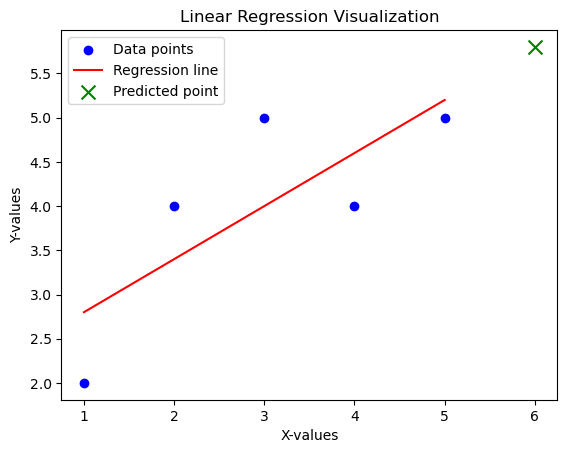

In [9]:
import matplotlib.pyplot as plt

# Sample data
x = [1, 2, 3, 4, 5]
y = [2, 4, 5, 4, 5]

# Calculate means
mean_x = sum(x) / len(x)
mean_y = sum(y) / len(y)

# Calculate slope (b1) and intercept (b0)
num = sum((x[i] - mean_x) * (y[i] - mean_y) for i in range(len(x)))
den = sum((x[i] - mean_x) ** 2 for i in range(len(x)))
b1 = num / den
b0 = mean_y - b1 * mean_x

print("The slope (coefficient) is:", b1)
print("The intercept value is:", b0)

# Predict new value
x_new = 6
y_new = b1 * x_new + b0
print("The new predicted value for y is:", y_new)

#  Visualization 
# Scatter plot of original data
plt.scatter(x, y, color="blue", label="Data points")

# Regression line
y_pred = [b0 + b1 * xi for xi in x]   # predicted values for each x
plt.plot(x, y_pred, color="red", label="Regression line")

# Highlight the new predicted point
plt.scatter(x_new, y_new, color="green", marker="x", s=100, label="Predicted point")

# Labels and legend
plt.title("Linear Regression Visualization")
plt.xlabel("X-values")
plt.ylabel("Y-values")
plt.legend()
plt.show()

## 20. What does a scatter plot show in Linear Regression?

##### What a Scatter Plot Represents
- Data points: Each dot represents an observation with its x (independent variable) and y (dependent variable) values.
- Pattern/trend: By looking at the cloud of points, you can visually assess whether there’s a linear relationship (points roughly forming a straight line), a non-linear relationship, or no clear relationship at all.
- Strength of relationship: If points lie close to a straight line, the correlation is strong. If they’re widely scattered, the relationship is weaker.
- Direction of relationship:
- Positive slope → as x increases, y tends to increase.
- Negative slope → as x increases, y tends to decrease.
- Outliers: Scatter plots make it easy to spot unusual points that don’t follow the general trend.


### 21. How do you identify underfitting from a plot?

Slope (b1): 8.0
Intercept (b0): -12.0
Predicted y for x = 8 is: 52.0


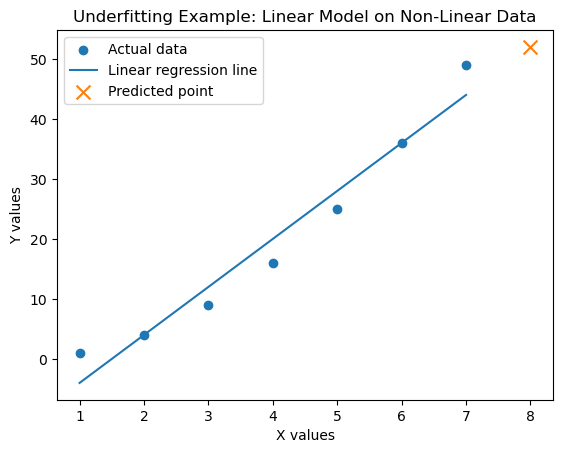

In [10]:
import matplotlib.pyplot as plt

# UNDERFITTING DATA (non-linear relationship)
x = [1, 2, 3, 4, 5, 6, 7]
y = [1, 4, 9, 16, 25, 36, 49]   # y = x^2 (quadratic curve)

# Calculate means
mean_x = sum(x) / len(x)
mean_y = sum(y) / len(y)

# Calculate slope (b1) and intercept (b0)
num = sum((x[i] - mean_x) * (y[i] - mean_y) for i in range(len(x)))
den = sum((x[i] - mean_x) ** 2 for i in range(len(x)))
b1 = num / den
b0 = mean_y - b1 * mean_x

print("Slope (b1):", b1)
print("Intercept (b0):", b0)

# Predict new value
x_new = 8
y_new = b1 * x_new + b0
print("Predicted y for x =", x_new, "is:", y_new)

# Visualization
plt.scatter(x, y, label="Actual data", marker="o")
y_pred = [b0 + b1 * xi for xi in x]
plt.plot(x, y_pred, label="Linear regression line")
plt.scatter(x_new, y_new, marker="x", s=100, label="Predicted point")

plt.title("Underfitting Example: Linear Model on Non-Linear Data")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.show()


# Underfitting in Machine Learning

Underfitting happens when a model is **too simple** to capture the pattern in the data.

---

#### 1. Model is Too Simple

##### Data vs Model Prediction Plot
- The model line is **almost straight or overly smooth**
- It **does not follow the data trend**

**Example:**
- Data shows a **curved or complex pattern**
- Model draws a **flat or straight line**

 This means the model **cannot learn the underlying relationship**.

---

#### 2. High Training and Testing Error

##### Loss / Error Plot
- **Training error is high**
- **Testing error is also high**
- Both errors are **close to each other**

 This indicates:
- The model is **not learning well**, even on training data.

---

#### 3. Residual Plot Shows Pattern

##### Residuals vs X Plot
- Residuals are **not randomly scattered**
- You see **curves or clear patterns**

 In a good model, residuals should look random.  
Patterns mean the model **missed important structure**.

---

#### 4. Bias–Variance Perspective

Underfitting is characterized by:
- **High bias**
- **Low variance**

##### Visual Meaning:
- Predictions are **consistently wrong in the same direction**

---

#### Summary

| Indicator | Observation |
|--------|------------|
| Model Complexity | Too simple |
| Data Pattern | Curved or complex |
| Training Error | High |
| Testing Error | High |
| Bias | High |
| Variance | Low |

---

##### One-Line Definition
**Underfitting occurs when a model is too simple to capture the true pattern in the data.**


### 22. How do you identify overfitting visually

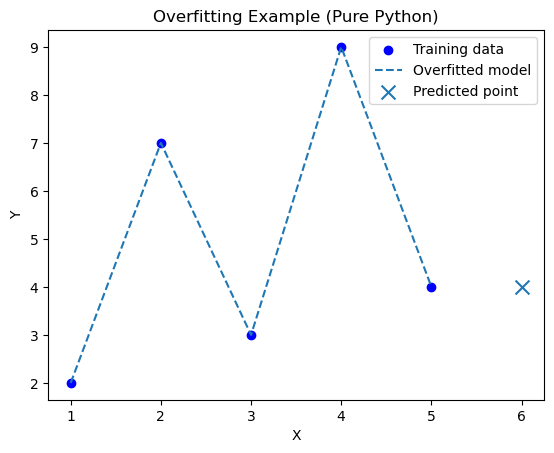

In [11]:
import matplotlib.pyplot as plt

# OVERFITTING DATA (noisy pattern)
x = [1, 2, 3, 4, 5]
y = [2, 7, 3, 9, 4]   # noisy, irregular data

# Sort data (important for curve)
data = sorted(zip(x, y))
x_sorted = [p[0] for p in data]
y_sorted = [p[1] for p in data]

# OVERFITTED MODEL
# Memorizes all points (passes through every one)
y_overfit = y_sorted

# New prediction (poor generalization)
x_new = 6
y_new = y_sorted[-1]   # bad prediction logic on purpose

# Plot
plt.scatter(x, y, label="Training data", color="blue")
plt.plot(x_sorted, y_overfit, label="Overfitted model", linestyle="--")
plt.scatter(x_new, y_new, marker="x", s=100, label="Predicted point")

plt.title("Overfitting Example (Pure Python)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()


# Overfitting in Machine Learning

Overfitting occurs when a model is **too complex** and learns the **noise** in the data instead of the true pattern.

---

#### 1. Model is Too Complex

##### Data vs Model Prediction Plot
- Model curve is **very wiggly**
- Fits **almost every data point**
- Captures noise instead of general trend

**Example:**
- Data pattern is simple
- Model uses a high-degree polynomial

 The model memorizes data instead of learning.

---

## 2. Low Training Error, High Testing Error

##### Loss / Error Plot
- **Training error is very low**
- **Testing error is high**
- Large gap between training and testing error

📊 This indicates poor generalization.

---

#### 3. Residual Plot Shows Random Noise on Training Data

##### Residuals vs X Plot
- Residuals on training data are very small
- Model fits noise, not the real pattern

---

#### 4. Bias–Variance Perspective

Overfitting is characterized by:
- **Low bias**
- **High variance**

##### Visual Meaning:
- Small change in data causes large change in predictions

---

#### Summary

| Indicator | Observation |
|--------|------------|
| Model Complexity | Too high |
| Training Error | Very low |
| Testing Error | High |
| Bias | Low |
| Variance | High |

---

##### One-Line Definition
**Overfitting occurs when a model fits training data too closely and fails to generalize to new data.**


### 23. What does the slope of the line indicate?



**Definition:**  
The slope of a line indicates how much the dependent variable (y) changes for a one-unit change in the independent variable (x).

**Key Points:**  
- **Positive slope (+):** y increases as x increases  
- **Negative slope (−):** y decreases as x increases  
- **Zero slope (0):** y does not change with x  

**Magnitude:**  
- Large slope → y changes quickly  
- Small slope → y changes slowly  

**Real-world Examples:**  
- House size vs price: Slope = 3000 → every 1 sq ft increase raises price by 3000 Rs.  
- Study hours vs marks: Slope = 5 → every extra hour adds 5 marks  

**ML Context:**  
- Slope = feature weight  
- Shows influence of a feature on the target variable


### 24. How do residual plots help in analysis?


**Definition:**  
A residual plot shows the difference between the actual and predicted values of a regression model.

**Why it helps:**  
Residual plots are a diagnostic tool that tells us **how well a regression model fits the data** and whether the assumptions of linear regression are met. Specifically, they help in:

1. **Checking model fit:**  
   - Residuals randomly scattered around zero → model captures the pattern well  
   - Patterned residuals (curves, waves) → model misses important trends → underfitting

2. **Detecting non-linearity:**  
   - If residuals show a systematic shape, it indicates the relationship between X and Y is not purely linear, so a more complex model might be needed.

3. **Identifying heteroscedasticity (unequal error spread):**  
   - Residuals that fan out or shrink as X changes indicate the variance of errors is not constant, violating regression assumptions.

4. **Finding outliers and influential points:**  
   - Points far from the zero line may disproportionately affect the model.

5. **Evaluating overfitting indirectly:**  
   - Very small residuals on training data but poor predictions on new data suggest the model memorized the data rather than learned the general trend.

**Examples:**  
- **House prices:** Residuals randomly scattered → linear model okay; residuals increasing with house size → model misses some patterns  
- **Student marks vs study hours:** U-shaped residuals → linear model does not capture the non-linear trend


### 25. What happens to the line when noise increases in data?

**Definition:**  
Noise is the random variation in data that cannot be explained by the independent variable.

**Effect on the Regression Line:**  
- The line still tries to capture the **average trend**.  
- As noise increases:  
  - Points scatter more widely around the line  
  - Residuals (errors) increase  
  - Slope and intercept may shift slightly  
- The overall **direction of the line remains**, but predictions become less precise.  

**Visual Intuition:**  
- **Low noise:** Points are close to the line → clear trend  
- **High noise:** Points are spread out → line follows the average but points are far from it  

**Examples:**  
- **House size vs price:** Random market fluctuations → line still represents average price trend, residuals increase  
- **Study hours vs exam marks:** Some students perform unusually high or low → line slope roughly the same, errors larger  
- **Temperature vs ice-cream sales:** One unusually hot or cold day → line follows general trend but points deviate  

**Summary:**  
> Increasing noise in data increases errors and reduces prediction precision, but the regression line still captures the average relationship.
